In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import re
from datetime import datetime

ecom = pd.read_csv('d:\\Ecommerce Analytics\\files\\ecommerce_data.csv')

In [2]:
ecom["PurchaseDate"]    = pd.to_datetime(ecom["PurchaseDate"],    errors="coerce")
ecom["RegistrationDate"]= pd.to_datetime(ecom["RegistrationDate"],errors="coerce")

In [31]:
for status in ecom['Status'].items():
    if status == 'completed':
        top5 = (ecom.groupby(["UserID","FirstName","LastName","State"])["TotalAmount"]
                .sum().sort_values(ascending=False).head(5).reset_index())
        top5.columns = ["UserID","FirstName","LastName", "State", "TotalSpend"]


print("Top 5 customers by spending:")
print(top5.to_string(index=False))

Top 5 customers by spending:
 UserID FirstName LastName  TotalSpend
    305     Henry    Smith    10807.01
     23       Ivy    Clark     9556.35
     32   Charlie Martinez     9471.86
    456      Jack    Davis     9279.70
    158     Frank  Jackson     9185.46


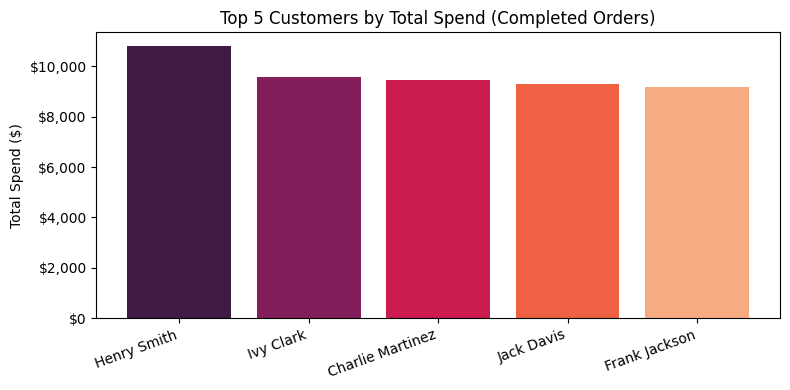

In [34]:
fig, ax = plt.subplots(figsize=(8, 4))
labels = top5["FirstName"] + " " + top5["LastName"]
ax.bar(labels, top5["TotalSpend"], color=sns.color_palette("rocket", 5))
ax.set_title("Top 5 Customers by Total Spend (Completed Orders)")
ax.set_ylabel("Total Spend ($)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
